In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.linalg import expm
from itertools import product

In [41]:
def comm(A,B):
    return A@B-B@A

In [64]:
a = 1

def TDDM(t,y,mu):
    # y carries all the coupled DE variables in a long vector\
    # rho is 2x2 but flattened into (4,)
    # c2 is 4x4 but flattened into (16,)
    rho = y[:4].reshape(2,2)
    c2 = y[4:].reshape(4,4)
    
    # set up the differentiated variables
    d_rho = np.zeros_like(rho, dtype=complex)
    d_c2 = np.zeros_like(c2, dtype=complex)

    # introduce hamiltonian components
    h0 = a/2*np.array([[1,-1],
                       [-1,1]],dtype=complex)
    v = np.array([[mu,0,0,0],
                  [0,0,0,0],
                  [0,0,0,0],
                  [0,0,0,mu]],dtype=complex)
    # H = np.array([[a+mu,-a/2,-a/2,0],
    #               [-a/2,a,0,-a/2],
    #               [-a/2,0,a,-a/2],
    #               [0,-a/2,-a/2,a+mu]], dtype=complex)
    H = np.kron(h0, np.eye(2,dtype=complex)) + np.kron(np.eye(2,dtype=complex), h0) + v
    
    # first d_rho equation
    d_rho += comm(h0,rho)

    comm4 = comm(v, np.kron(rho,rho)+c2)
    comm4 = comm4.reshape(2,2,2,2)
    tr2 = np.trace(comm4, axis1=1, axis2=3) # to trace over particle 2
    d_rho += tr2
    
    d_rho = -1j*d_rho
    assert d_rho.shape == (2,2)
    
    

    # now d_c2 equation
    d_c2 += comm(H, c2)
    d_c2 += comm(v, np.kron(rho,rho))

    # now the trace over 3 term:
    v23 = np.kron(np.eye(2,dtype=complex),v)
    # need permutation matrix to get v13, where v13 = P23 v12 P23
    P23 = np.array([[1, 0, 0, 0, 0, 0, 0, 0],
                    [0, 0, 1, 0, 0, 0, 0, 0],
                    [0, 1, 0, 0, 0, 0, 0, 0],
                    [0, 0, 0, 1, 0, 0, 0, 0],
                    [0, 0, 0, 0, 1, 0, 0, 0],
                    [0, 0, 0, 0, 0, 0, 1, 0],
                    [0, 0, 0, 0, 0, 1, 0, 0],
                    [0, 0, 0, 0, 0, 0, 0, 1]], dtype=complex)
    v13 = P23 @ np.kron(v,np.eye(2,dtype=complex)) @ P23.T.conj()
    comm8 = comm( v13 + v23, np.kron(np.kron(rho,rho),rho) + np.kron(rho,c2) )
    comm8 = comm8.reshape(2,2,2,2,2,2)
    tr3 = np.trace(comm8, axis1=2, axis2=5)
    tr3 = tr3.reshape(4,4)
    d_c2 += tr3
    
    d_c2 = -1j*d_c2
    assert d_c2.shape == (4,4)

    d_all = np.concatenate(( d_rho.ravel(), d_c2.ravel() ))
    assert d_all.shape == (20,)
    
    return d_all

In [65]:
mu = -4

rho0 = np.zeros((2, 2), dtype=complex)
c20 = np.zeros((4, 4), dtype=complex)

# for all particles initialli in L:
rho0[0,0] = 3

y0 = np.concatenate(( rho0.ravel(), c20.ravel() ))


"""
Consistency checks for integration

'assert' continues on if answer is True, or raises error if False
""" 
assert rho0.shape == (2,2)
assert c20.shape == (4,4)
assert y0.shape == (20,)

# Evaluate the RHS once to catch indexing errors.
test_derivative = TDDM(t=0.0,y=y0,mu=mu)
assert test_derivative.shape == y0.shape
assert np.all(np.isfinite(test_derivative))

print("Initial state shape:", y0.shape)
print("Initial derivative shape:", test_derivative.shape)

Initial state shape: (20,)
Initial derivative shape: (20,)


In [77]:
"""
And now we integrate
"""

t_list = np.linspace(0.0,20.0,1001)
soln = solve_ivp( 
    fun=lambda t, y: TDDM(t,y,mu),
    t_span = (t_list[0],t_list[-1]), 
    y0 = y0,
    t_eval = t_list,
    method = "DOP853", # got same result with BDF and DOP853, crashes at same spot 
    rtol=1e-9,
    atol=1e-11,
)

if not soln.success:
    raise RuntimeError(
        f"Integration failed: {soln.message}"
    )

RuntimeError: Integration failed: Required step size is less than spacing between numbers.

In [78]:
rho_soln = soln.y[:4,:].reshape(2,2,len(soln.t))
c2_soln = soln.y[4:,:].reshape(4,4,len(soln.t))

rho_kron = np.einsum("abt,cdt->acbdt", rho_soln, rho_soln)
rho_kron = rho_kron.reshape(4, 4, rho_soln.shape[2])
rho2_soln = rho_kron + c2_soln

print("rho_solution shape:", rho_soln.shape)
print("c2_solution shape:", c2_soln.shape)
print("rho2_solution shape:", rho2_soln.shape)

rho_solution shape: (2, 2, 317)
c2_solution shape: (4, 4, 317)
rho2_solution shape: (4, 4, 317)


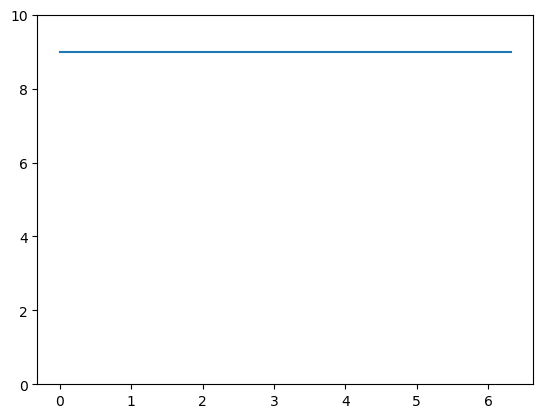

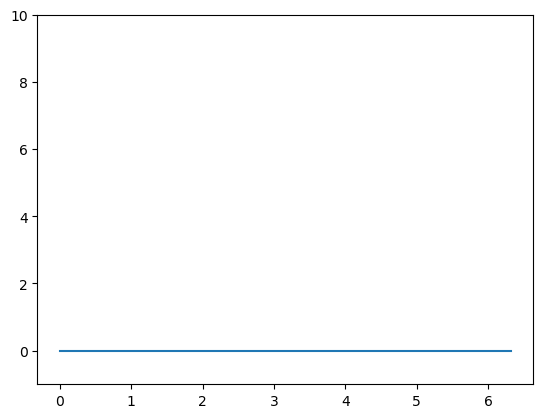

In [69]:
"""
Check purity
"""
# this was purity of 1body rho
# rhosq = np.einsum("ijt,jkt->ikt",rho_soln,rho_soln)
# plt.plot(t_list,np.trace(rhosq, axis1=0,axis2=1))
# plt.show()

# purity of twobody rho
plt.plot(soln.t,np.trace(rho2_soln,axis1=0,axis2=1))
plt.ylim(0,10)
plt.show()

# purity of correlation part only
# plt.plot(t_list,np.trace(rho2_soln-rho_kron,axis1=0,axis2=1))
plt.plot(soln.t,np.trace(c2_soln,axis1=0,axis2=1))
plt.ylim(-1,10)
plt.show()

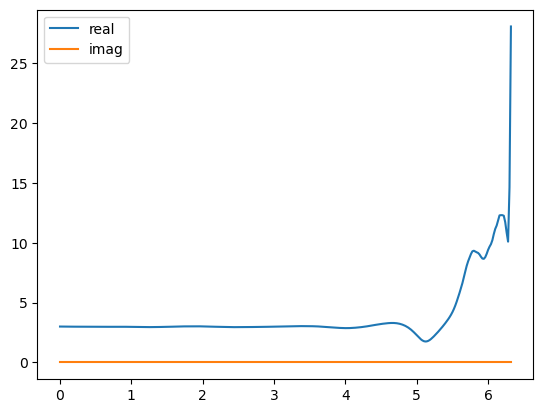

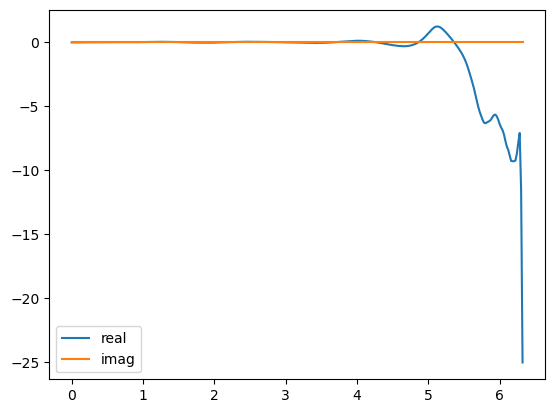

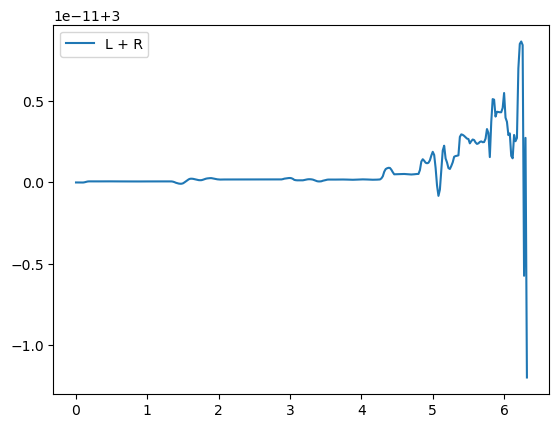

In [70]:
"""
These dont have much physical meaning, just checking components of 1body rho
"""

plt.plot(soln.t,rho_soln[0,0].real,label='real')
plt.plot(soln.t,rho_soln[0,0].imag,label='imag')
plt.legend()
plt.show()

plt.plot(soln.t,rho_soln[1,1].real,label='real')
plt.plot(soln.t,rho_soln[1,1].imag,label='imag')
plt.legend()
plt.show()

plt.plot(soln.t,rho_soln[0,0].real+rho_soln[1,1].real,label='L + R')
plt.legend()
plt.show()

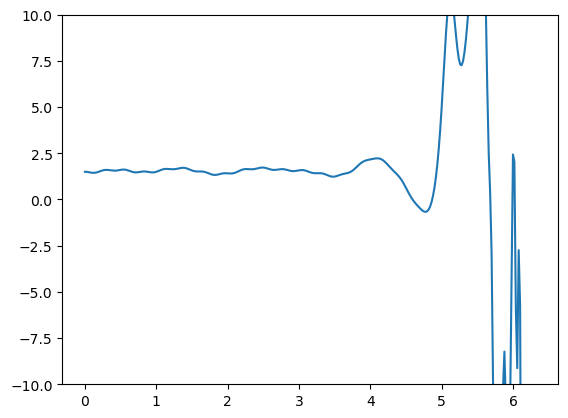

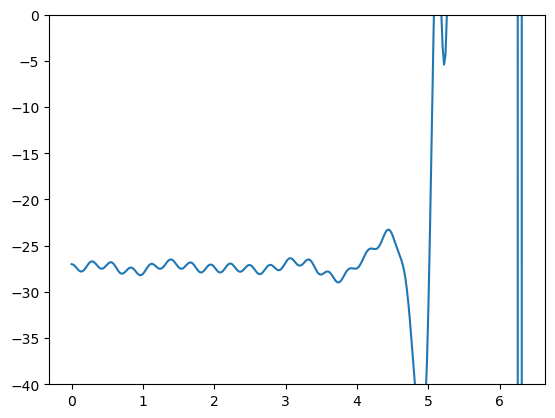

In [75]:
"""
Check energy conservation
"""
a=1

h0 = a/2*np.array([[1,-1],
                   [-1,1]],dtype=complex)
v = np.array([[mu,0,0,0],
              [0,0,0,0],
              [0,0,0,0],
              [0,0,0,mu]],dtype=complex)
H = np.array([[a+mu,-a/2,-a/2,0],
              [-a/2,a,0,-a/2],
              [-a/2,0,a,-a/2],
              [0,-a/2,-a/2,a+mu]], dtype=complex)

# kinetic first
T = np.trace( np.einsum("ijt,jk->ikt",rho_soln,h0), axis1=0, axis2=1)
# now total
E = np.trace( np.einsum("ijt,jk->ikt",rho2_soln,H), axis1=0, axis2=1)

plt.plot(soln.t,T)
plt.ylim(-10,10)
plt.show()

plt.plot(soln.t,E)
plt.ylim(-40,0)
plt.show()

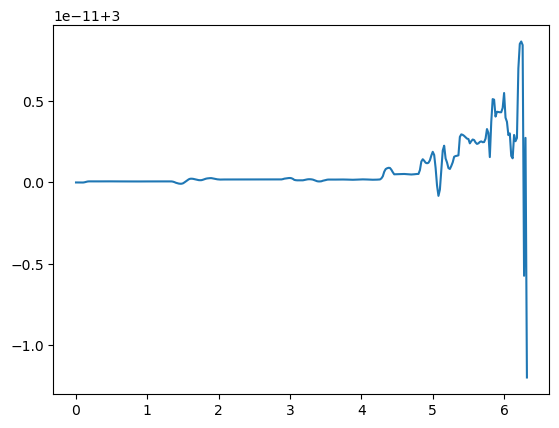

In [76]:
"""
particle number should be conserved
"""

plt.plot(soln.t,np.trace(rho_soln,axis1=0,axis2=1))
plt.show()